# Publication-Style CTA VAI Plot: Jitter + Mean + 95% CI + Significance

This notebook reads your long-format A–E image-level dataset and creates a cleaner paper-ready figure for **CTA VAI (%)**.

### Plot design
- **Raw image-level points** for each condition
- slight horizontal jitter so overlapping points remain visible
- **Mean** per condition
- **95% confidence interval**
- optional faint paired lines connecting the same ad across A–E
- significance brackets for selected post-hoc comparisons

### Expected input files
```text
data/A_to_E_long_image_level_data.csv
data/A_to_E_repeated_measures_posthoc.csv
```


In [1]:
# Install once if needed:
# %pip install pandas numpy matplotlib scipy

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


## 1. Configuration

In [2]:
LONG_CSV = "data/A_to_E_long_image_level_data.csv"
POSTHOC_CSV = "data/A_to_E_repeated_measures_posthoc.csv"

AOI = "CTA"
METRIC = "VAI (%)"

CONDITION_ORDER = ["A", "B", "C", "D", "E"]

# Only show the comparisons most relevant to condition C
SIGNIFICANCE_PAIRS = [
    ("A", "C"),
    ("B", "C"),
    ("C", "D"),
    ("C", "E"),
]

SHOW_PAIRED_LINES = True
ALPHA = 0.05

OUTPUT_PNG = "CTA_VAI_publication_plot.png"
OUTPUT_PDF = "CTA_VAI_publication_plot.pdf"

RANDOM_SEED = 42


## 2. Load the data

In [3]:
for f in [LONG_CSV, POSTHOC_CSV]:
    if not Path(f).exists():
        raise FileNotFoundError(
            f"Could not find {f}. Check the path in the configuration cell."
        )

long_df = pd.read_csv(LONG_CSV)
posthoc = pd.read_csv(POSTHOC_CSV)

for frame in [long_df, posthoc]:
    frame.columns = [str(c).replace("**", "").strip() for c in frame.columns]

focus = long_df[
    (long_df["AOI"] == AOI)
    & (long_df["metric"] == METRIC)
    & (long_df["condition"].isin(CONDITION_ORDER))
].copy()

focus["value"] = pd.to_numeric(focus["value"], errors="coerce")
focus = focus.dropna(subset=["value"])

print("Rows used:", len(focus))
print("Images:", focus["Img"].nunique())

focus.head()


Rows used: 97
Images: 20


,Img,AOI,condition,metric,value
0,1,CTA,A,VAI (%),0.0
1,1,CTA,B,VAI (%),11.9
2,1,CTA,C,VAI (%),27.8
3,1,CTA,D,VAI (%),11.1
4,1,CTA,E,VAI (%),16.4


## 3. Compute means and 95% confidence intervals

In [4]:
summary_rows = []

for cond in CONDITION_ORDER:
    vals = focus.loc[
        focus["condition"] == cond,
        "value"
    ].dropna().astype(float).values

    n = len(vals)
    mean = np.mean(vals)
    sd = np.std(vals, ddof=1)

    if n > 1:
        se = sd / np.sqrt(n)
        tcrit = stats.t.ppf(0.975, df=n - 1)
        ci = tcrit * se
    else:
        ci = np.nan

    summary_rows.append({
        "condition": cond,
        "n": n,
        "mean": mean,
        "sd": sd,
        "ci95": ci,
        "lower": mean - ci if np.isfinite(ci) else np.nan,
        "upper": mean + ci if np.isfinite(ci) else np.nan,
    })

summary = pd.DataFrame(summary_rows)
summary


,condition,n,mean,sd,ci95,lower,upper
0,A,20,19.265000,15.686074,7.341309,11.923691,26.606309
1,B,20,26.680000,14.740799,6.898906,19.781094,33.578906
2,C,20,33.870000,13.099421,6.130718,27.739282,40.000718
3,D,19,24.421053,15.817310,7.623700,16.797353,32.044752
4,E,18,28.222222,13.510630,6.718678,21.503544,34.940900


## 4. Helper functions for post-hoc q-values

In [5]:
def get_pair_row(g1, g2):
    mask = (
        (posthoc["AOI"] == AOI)
        & (posthoc["metric"] == METRIC)
        & (
            (
                (posthoc["group1"] == g1)
                & (posthoc["group2"] == g2)
            )
            |
            (
                (posthoc["group1"] == g2)
                & (posthoc["group2"] == g1)
            )
        )
    )

    rows = posthoc.loc[mask]

    if len(rows) == 0:
        return None

    return rows.iloc[0]


def format_q(q):
    if pd.isna(q):
        return ""
    if q < 0.001:
        return "q < .001"
    return f"q = {q:.3f}"


## 5. Create the publication-style plot

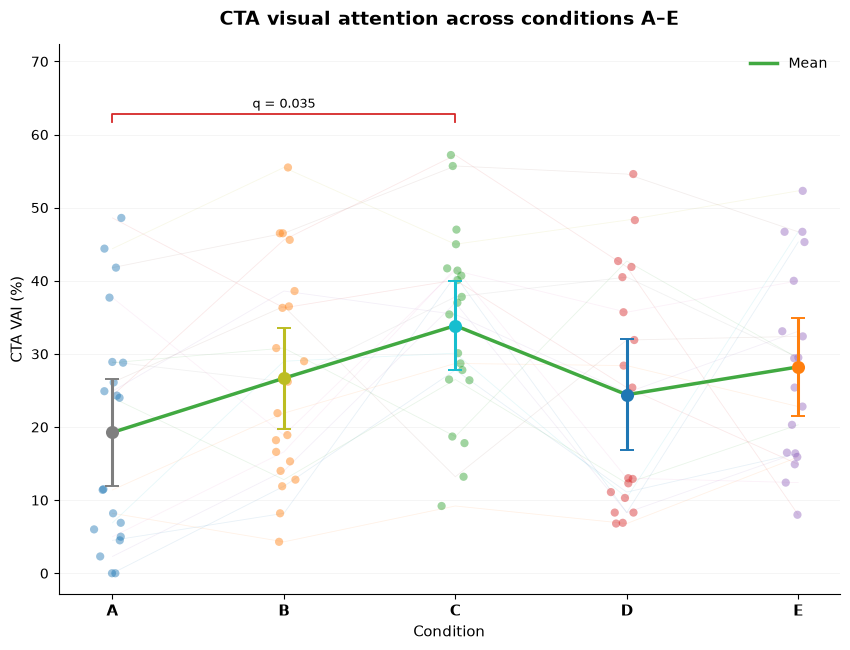

Saved: CTA_VAI_publication_plot.png
Saved: CTA_VAI_publication_plot.pdf


In [6]:
rng = np.random.default_rng(RANDOM_SEED)

fig, ax = plt.subplots(figsize=(8.6, 6.6))

x_positions = {
    cond: i for i, cond in enumerate(CONDITION_ORDER)
}

# Optional paired lines connecting the same image across conditions
if SHOW_PAIRED_LINES:
    pivot = focus.pivot(
        index="Img",
        columns="condition",
        values="value"
    )

    available_conditions = [
        c for c in CONDITION_ORDER if c in pivot.columns
    ]

    complete = pivot[available_conditions].dropna()

    for _, row in complete.iterrows():
        xs = [x_positions[c] for c in available_conditions]
        ys = [row[c] for c in available_conditions]

        ax.plot(
            xs,
            ys,
            linewidth=0.6,
            alpha=0.10,
            zorder=1
        )

# Raw jittered points
for cond in CONDITION_ORDER:
    vals = focus.loc[
        focus["condition"] == cond,
        "value"
    ].dropna().astype(float).values

    x0 = x_positions[cond]

    jitter = rng.normal(
        loc=0.0,
        scale=0.055,
        size=len(vals)
    )

    ax.scatter(
        np.full(len(vals), x0) + jitter,
        vals,
        s=35,
        alpha=0.45,
        edgecolors="none",
        zorder=2
    )

# Mean + 95% CI
for _, r in summary.iterrows():
    x = x_positions[r["condition"]]

    ax.errorbar(
        x,
        r["mean"],
        yerr=r["ci95"],
        fmt="o",
        markersize=8,
        capsize=5,
        elinewidth=2.2,
        markeredgewidth=1.4,
        zorder=4
    )

# Connect condition means
ax.plot(
    [x_positions[c] for c in CONDITION_ORDER],
    [
        summary.loc[
            summary["condition"] == c,
            "mean"
        ].iloc[0]
        for c in CONDITION_ORDER
    ],
    linewidth=2.5,
    alpha=0.9,
    zorder=3,
    label="Mean"
)

# Determine y range for significance brackets
ymax_data = focus["value"].max()
ymin_data = focus["value"].min()
yrange = max(1.0, ymax_data - ymin_data)

base_y = ymax_data + 0.08 * yrange
step = 0.085 * yrange

# Only draw brackets for selected comparisons that survive global post-hoc FDR
bracket_index = 0

for g1, g2 in SIGNIFICANCE_PAIRS:
    row = get_pair_row(g1, g2)

    if row is None:
        continue

    q = pd.to_numeric(
        pd.Series([row.get("q_posthoc_global_FDR")]),
        errors="coerce"
    ).iloc[0]

    sig = bool(row.get("significant_posthoc_global_FDR", False))

    if not sig or not np.isfinite(q):
        continue

    x1 = x_positions[g1]
    x2 = x_positions[g2]

    y = base_y + bracket_index * step
    h = 0.018 * yrange

    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        linewidth=1.3,
        zorder=5
    )

    ax.text(
        (x1 + x2) / 2,
        y + h + 0.008 * yrange,
        format_q(q),
        ha="center",
        va="bottom",
        fontsize=9,
        zorder=6
    )

    bracket_index += 1

# Axes
ax.set_xticks(
    [x_positions[c] for c in CONDITION_ORDER]
)
ax.set_xticklabels(
    CONDITION_ORDER,
    fontsize=11,
    fontweight="bold"
)

ax.set_xlabel(
    "Condition",
    fontsize=11
)

ax.set_ylabel(
    "CTA VAI (%)",
    fontsize=11
)

ax.set_title(
    "CTA visual attention across conditions A–E",
    fontsize=14,
    fontweight="bold",
    pad=14
)

# Expand y-axis if significance brackets exist
if bracket_index > 0:
    ax.set_ylim(
        ymin_data - 0.05 * yrange,
        base_y + bracket_index * step + 0.10 * yrange
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linewidth=0.5,
    alpha=0.18
)

ax.legend(
    frameon=False,
    loc="best"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_PNG,
    dpi=400,
    bbox_inches="tight"
)

fig.savefig(
    OUTPUT_PDF,
    bbox_inches="tight"
)

plt.show()

print("Saved:", OUTPUT_PNG)
print("Saved:", OUTPUT_PDF)


## 6. Inspect the statistics shown on the plot

This table shows the four C-focused comparisons and whether they survived the global post-hoc FDR correction.


In [7]:
rows = []

for g1, g2 in SIGNIFICANCE_PAIRS:
    r = get_pair_row(g1, g2)

    if r is None:
        rows.append({
            "comparison": f"{g1}-{g2}",
            "q_posthoc_global_FDR": np.nan,
            "significant": False,
        })
    else:
        rows.append({
            "comparison": f"{g1}-{g2}",
            "q_posthoc_global_FDR": r.get(
                "q_posthoc_global_FDR",
                np.nan
            ),
            "significant": r.get(
                "significant_posthoc_global_FDR",
                False
            ),
        })

pd.DataFrame(rows)


,comparison,q_posthoc_global_FDR,significant
0,A-C,0.034510,True
1,B-C,0.134071,False
2,C-D,0.134071,False
3,C-E,0.304841,False


## Interpretation

This figure should be read as:

- small points = individual ad images
- faint lines = the same ad across A–E
- large point = condition mean
- error bar = 95% confidence interval
- connecting thick line = mean trend
- significance bracket = pairwise difference that survives global post-hoc BH-FDR

For your paper, this is much cleaner than showing 20 strongly colored trajectories.
